In [2]:
# CONFIGURATION
N_BASE_IMAGES = 100        # number of base images to select
START_ID      = 2_000_000  # test IDs start here — no overlap with main dataset
RANDOM_SEED   = 42         # for reproducibility — do not change

KAGGLE_INPUT  = '/kaggle/input/datasets/sohangundoju/mirflickr-1m'
OUTPUT_DIR    = '/kaggle/working/test_dataset'
GT_PATH       = '/kaggle/working/ground_truth.json'

In [3]:
import os
import io
import glob
import json
import random
import numpy as np
from PIL import Image, ImageEnhance
from tqdm import tqdm

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✓ Imports done")
print(f"  Output dir : {OUTPUT_DIR}")

✓ Imports done
  Output dir : /kaggle/working/test_dataset


In [4]:
# FIND ALL IMAGES IN DATASET AND PICK 100
# We use Pack 1 only (images0) to keep things simple and fast.
# ─────────────────────────────────────────────────────────────────────────────

pack1_folder = os.path.join(KAGGLE_INPUT, 'images0', 'images')

print(f"Scanning {pack1_folder} ...")

all_paths = sorted(list(set([
    os.path.abspath(p)
    for p in glob.glob(os.path.join(pack1_folder, '**/*.jpg'), recursive=True)
])))

print(f"✓ Found {len(all_paths)} images in Pack 1")

# Randomly select 100 diverse base images
selected_paths = random.sample(all_paths, N_BASE_IMAGES)
selected_paths = sorted(selected_paths)   # sort for reproducibility

print(f"✓ Selected {len(selected_paths)} base images")
print(f"  First: {os.path.basename(selected_paths[0])}")
print(f"  Last : {os.path.basename(selected_paths[-1])}")



Scanning /kaggle/input/datasets/sohangundoju/mirflickr-1m/images0/images ...
✓ Found 100000 images in Pack 1
✓ Selected 100 base images
  First: 1764.jpg
  Last : 99458.jpg


In [5]:
# GENERATE 5 VARIANTS PER BASE IMAGE
# ─────────────────────────────────────────────────────────────────────────────

ground_truth = {}
current_id   = START_ID
failed        = []

print(f"\nGenerating variants for {N_BASE_IMAGES} base images ...")
print(f"Total output: {N_BASE_IMAGES * 6} images (1 base + 5 variants each)")
print("-" * 50)

for base_path in tqdm(selected_paths, desc="Generating", unit="img"):
    try:
        img    = Image.open(base_path).convert('RGB')
        w, h   = img.size
        base_id = current_id

        # ── Save base image ───────────────────────────────────────────────────
        img.save(os.path.join(OUTPUT_DIR, f'{base_id}.jpg'), quality=95)
        current_id += 1
        variant_ids = []

        # ── Variant 1: JPEG compression ───────────────────────────────────────
        # Heavy compression (quality=25) — simulates re-uploaded web images
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=25)
        buf.seek(0)
        Image.open(buf).convert('RGB').save(
            os.path.join(OUTPUT_DIR, f'{current_id}.jpg'))
        variant_ids.append(current_id)
        current_id += 1

        # ── Variant 2: Random crop (retains ~85% of image) ────────────────────
        margin_x = int(w * 0.08)
        margin_y = int(h * 0.08)
        left     = random.randint(0, margin_x)
        top      = random.randint(0, margin_y)
        right    = w - random.randint(0, margin_x)
        bottom   = h - random.randint(0, margin_y)
        img.crop((left, top, right, bottom)).resize(
            (w, h), Image.BILINEAR).save(
            os.path.join(OUTPUT_DIR, f'{current_id}.jpg'))
        variant_ids.append(current_id)
        current_id += 1

        # ── Variant 3: Brightness increase ───────────────────────────────────
        ImageEnhance.Brightness(img).enhance(1.6).save(
            os.path.join(OUTPUT_DIR, f'{current_id}.jpg'))
        variant_ids.append(current_id)
        current_id += 1

        # ── Variant 4: Horizontal flip ────────────────────────────────────────
        img.transpose(Image.FLIP_LEFT_RIGHT).save(
            os.path.join(OUTPUT_DIR, f'{current_id}.jpg'))
        variant_ids.append(current_id)
        current_id += 1

        # ── Variant 5: Gaussian noise ─────────────────────────────────────────
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, 20, arr.shape)
        noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
        Image.fromarray(noisy).save(
            os.path.join(OUTPUT_DIR, f'{current_id}.jpg'))
        variant_ids.append(current_id)
        current_id += 1

        # ── Record in ground truth ────────────────────────────────────────────
        ground_truth[base_id] = variant_ids

    except Exception as e:
        failed.append((base_path, str(e)))
        current_id += 6   # skip IDs to maintain spacing
        continue

print(f"\n✓ Generation complete")
print(f"  Base images    : {len(ground_truth)}")
print(f"  Failed         : {len(failed)}")
print(f"  Total images   : {len(ground_truth) * 6}")
print(f"  ID range       : {START_ID} → {current_id - 1}")

if failed:
    print(f"\n  Failed images:")
    for path, err in failed[:5]:
        print(f"    {os.path.basename(path)}: {err}")


Generating variants for 100 base images ...
Total output: 600 images (1 base + 5 variants each)
--------------------------------------------------


Generating: 100%|██████████| 100/100 [00:04<00:00, 22.89img/s]


✓ Generation complete
  Base images    : 100
  Failed         : 0
  Total images   : 600
  ID range       : 2000000 → 2000599


In [6]:
# SAVE GROUND TRUTH JSON
# ─────────────────────────────────────────────────────────────────────────────

with open(GT_PATH, 'w') as f:
    json.dump(ground_truth, f, indent=2)

print(f"✓ Ground truth saved: {GT_PATH}")
print(f"  Entries : {len(ground_truth)}")

# Show sample
print(f"\nSample entries:")
for base_id, variants in list(ground_truth.items())[:3]:
    print(f"  {base_id} → {variants}")

✓ Ground truth saved: /kaggle/working/ground_truth.json
  Entries : 100

Sample entries:
  2000000 → [2000001, 2000002, 2000003, 2000004, 2000005]
  2000006 → [2000007, 2000008, 2000009, 2000010, 2000011]
  2000012 → [2000013, 2000014, 2000015, 2000016, 2000017]


In [7]:
# VERIFY OUTPUT
# ─────────────────────────────────────────────────────────────────────────────

saved_files = glob.glob(os.path.join(OUTPUT_DIR, '*.jpg'))
print(f"\n✓ Verification:")
print(f"  Expected files : {len(ground_truth) * 6}")
print(f"  Actual files   : {len(saved_files)}")
print(f"  Match          : {'✓ YES' if len(saved_files) == len(ground_truth) * 6 else '✗ NO'}")

# Verify IDs in ground truth match saved files
saved_ids = set(int(os.path.splitext(os.path.basename(f))[0]) for f in saved_files)
gt_all_ids = set()
for base_id, variants in ground_truth.items():
    gt_all_ids.add(base_id)
    gt_all_ids.update(variants)

print(f"  ID alignment   : {'✓ YES' if saved_ids == gt_all_ids else '✗ MISMATCH'}")


✓ Verification:
  Expected files : 600
  Actual files   : 600
  Match          : ✓ YES
  ID alignment   : ✓ YES


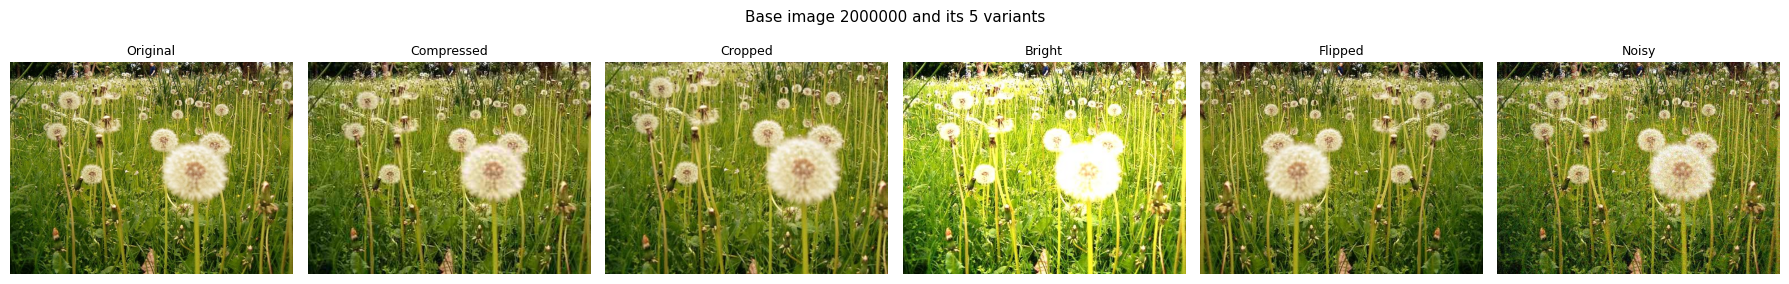

✓ Sample visualization saved to /kaggle/working/variant_sample.png


In [8]:
# VISUALLY INSPECT A FEW VARIANTS (OPTIONAL SANITY CHECK)
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

sample_base_id = list(ground_truth.keys())[0]
sample_variants = ground_truth[sample_base_id]
all_sample_ids  = [sample_base_id] + sample_variants
labels          = ['Original', 'Compressed', 'Cropped', 'Bright', 'Flipped', 'Noisy']

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, img_id, label in zip(axes, all_sample_ids, labels):
    img_path = os.path.join(OUTPUT_DIR, f'{img_id}.jpg')
    img      = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Base image {sample_base_id} and its 5 variants', fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/variant_sample.png', dpi=100)
plt.show()
print("✓ Sample visualization saved to /kaggle/working/variant_sample.png")


In [9]:
import shutil

# Zip the entire test_dataset folder into one file
shutil.make_archive(
    '/kaggle/working/test_dataset',   # output zip name
    'zip',                             # format
    '/kaggle/working',                 # root directory
    'test_dataset'                     # folder to zip
)

print(f"✓ Zipped: /kaggle/working/test_dataset.zip")
print(f"  Size: {os.path.getsize('/kaggle/working/test_dataset.zip') / 1e6:.1f} MB")
print("  Download test_dataset.zip from the Output panel")

✓ Zipped: /kaggle/working/test_dataset.zip
  Size: 27.1 MB
  Download test_dataset.zip from the Output panel
